<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/QDA_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Власна реалізація QDA

**Курс:** Numerical Programming in Python  
**Тема 8:** Алгоритми LDA та QDA у задачах класифікації

У роботі реалізовано квадратичний дискримінантний аналіз (QDA) без використання готового класифікатора для основних обчислень. Результати порівнюються з `sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis`.

**Обраний підхід до здачі:** намагатися отримати вищий бал шляхом можливого доопрацювання роботи відповідно до фідбеку ментора.


## 1. Імпорт бібліотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.set_printoptions(precision=4, suppress=True)


## 2. Завантаження набору даних Iris

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y
df["class_name"] = [iris.target_names[label] for label in y]

print("Розмір вибірки:", X.shape)
print("Класи:", iris.target_names)
df.head()


Розмір вибірки: (150, 4)
Класи: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Поділ даних на навчальну та тестову вибірки

Використовуємо `stratify=y`, щоб зберегти співвідношення класів у навчальній і тестовій вибірках.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)
print("Кількість об'єктів кожного класу в train:", np.bincount(y_train))
print("Кількість об'єктів кожного класу в test:", np.bincount(y_test))


Навчальна вибірка: (105, 4)
Тестова вибірка: (45, 4)
Кількість об'єктів кожного класу в train: [35 35 35]
Кількість об'єктів кожного класу в test: [15 15 15]


## 4. Вибірки ознак окремо для кожного класу

In [4]:
classes = np.unique(y_train)
X_by_class = {class_id: X_train[y_train == class_id] for class_id in classes}

for class_id, class_samples in X_by_class.items():
    print(f"Клас {class_id} ({iris.target_names[class_id]}): {class_samples.shape}")


Клас 0 (setosa): (35, 4)
Клас 1 (versicolor): (35, 4)
Клас 2 (virginica): (35, 4)


## 5. Середні вектори, коваріаційні матриці та апріорні ймовірності

Для кожного класу обчислюємо:

- середній вектор $\mu_k$;
- коваріаційну матрицю $\Sigma_k$;
- обернену коваріаційну матрицю $\Sigma_k^{-1}$;
- апріорну ймовірність $P(C_k)$.

Для числової стабільності до діагоналі коваріаційної матриці додається мале число `regularization`.


In [5]:
def estimate_qda_parameters(X_train, y_train, regularization=1e-6):
    """Обчислює параметри QDA окремо для кожного класу."""
    classes = np.unique(y_train)
    means = {}
    covariances = {}
    inverse_covariances = {}
    determinants = {}
    priors = {}

    n_samples = len(y_train)

    for class_id in classes:
        X_class = X_train[y_train == class_id]

        mean_vector = np.mean(X_class, axis=0)
        covariance_matrix = np.cov(X_class, rowvar=False)
        covariance_matrix = (
            covariance_matrix
            + regularization * np.eye(X_train.shape[1])
        )

        means[class_id] = mean_vector
        covariances[class_id] = covariance_matrix
        inverse_covariances[class_id] = np.linalg.inv(covariance_matrix)
        determinants[class_id] = np.linalg.det(covariance_matrix)
        priors[class_id] = len(X_class) / n_samples

    return {
        "classes": classes,
        "means": means,
        "covariances": covariances,
        "inverse_covariances": inverse_covariances,
        "determinants": determinants,
        "priors": priors,
    }


params = estimate_qda_parameters(X_train, y_train)

for class_id in params["classes"]:
    print(f"\nКлас {class_id} ({iris.target_names[class_id]})")
    print("Середній вектор:")
    print(params["means"][class_id])
    print("Коваріаційна матриця:")
    print(params["covariances"][class_id])
    print("Обернена коваріаційна матриця:")
    print(params["inverse_covariances"][class_id])
    print("Апріорна ймовірність:", params["priors"][class_id])



Клас 0 (setosa)
Середній вектор:
[4.9886 3.4257 1.4857 0.24  ]
Коваріаційна матриця:
[[0.1063 0.1079 0.0089 0.0128]
 [0.1079 0.179  0.0157 0.0125]
 [0.0089 0.0157 0.0236 0.0038]
 [0.0128 0.0125 0.0038 0.0095]]
Обернена коваріаційна матриця:
[[ 26.4714 -15.0091   2.6908 -17.0583]
 [-15.0091  14.8571  -4.5925   2.5972]
 [  2.6908  -4.5925  47.0443 -16.485 ]
 [-17.0583   2.5972 -16.485  131.0951]]
Апріорна ймовірність: 0.3333333333333333

Клас 1 (versicolor)
Середній вектор:
[5.9486 2.7314 4.2371 1.3086]
Коваріаційна матриця:
[[0.2479 0.0699 0.1723 0.0481]
 [0.0699 0.0881 0.0612 0.0315]
 [0.1723 0.0612 0.2177 0.0658]
 [0.0481 0.0315 0.0658 0.0367]]
Обернена коваріаційна матриця:
[[  9.9353  -4.0178  -8.3917   5.4836]
 [ -4.0178  18.0551   2.6275 -14.9432]
 [ -8.3917   2.6275  17.1721 -22.0726]
 [  5.4836 -14.9432 -22.0726  72.5048]]
Апріорна ймовірність: 0.3333333333333333

Клас 2 (virginica)
Середній вектор:
[6.6829 3.0086 5.6314 2.0686]
Коваріаційна матриця:
[[0.4373 0.1063 0.3358 0.03

## 6. Дискримінантна функція QDA

Для класу $k$ використовується функція:

$$
g_k(x) =
-\frac{1}{2}\ln|\Sigma_k|
-\frac{1}{2}(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)
+\ln P(C_k).
$$

Об'єкт відноситься до класу, для якого значення $g_k(x)$ є найбільшим.


In [6]:
def qda_discriminant_one(x, params):
    """Обчислює дискримінантні значення для одного вектора ознак."""
    scores = []

    for class_id in params["classes"]:
        mean = params["means"][class_id]
        inv_cov = params["inverse_covariances"][class_id]
        det_cov = params["determinants"][class_id]
        prior = params["priors"][class_id]

        diff = x - mean
        quadratic_term = diff.T @ inv_cov @ diff

        score = (
            -0.5 * np.log(det_cov)
            -0.5 * quadratic_term
            + np.log(prior)
        )
        scores.append(score)

    return np.array(scores)


example_scores = qda_discriminant_one(X_test[0], params)
print("Перший тестовий об'єкт:", X_test[0])
print("Значення дискримінантних функцій:", example_scores)


Перший тестовий об'єкт: [7.3 2.9 6.3 1.8]
Значення дискримінантних функцій: [-644.1261   -6.9977    1.3653]


## 7. Прогнозування та ймовірності для всієї тестової матриці

Значення дискримінантних функцій перетворюються на ймовірності за допомогою чисельно стабільного softmax.


In [7]:
def softmax(scores):
    """Чисельно стабільний softmax."""
    shifted = scores - np.max(scores)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores)


def qda_predict(X, params):
    """Повертає класи, ймовірності та дискримінантні значення."""
    all_scores = np.array([
        qda_discriminant_one(x, params) for x in X
    ])
    probabilities = np.array([
        softmax(scores) for scores in all_scores
    ])
    class_indices = np.argmax(all_scores, axis=1)
    predictions = params["classes"][class_indices]

    return predictions, probabilities, all_scores


y_pred_custom, proba_custom, scores_custom = qda_predict(X_test, params)

results_custom = pd.DataFrame({
    "actual": y_test,
    "predicted_custom": y_pred_custom,
    "prob_setosa": proba_custom[:, 0],
    "prob_versicolor": proba_custom[:, 1],
    "prob_virginica": proba_custom[:, 2],
})

results_custom.head(10)


,actual,predicted_custom,prob_setosa,prob_versicolor,prob_virginica
0,2,2,4.640301e-281,2.332795e-04,9.997667e-01
1,1,1,5.879362e-126,9.923218e-01,7.678230e-03
2,2,1,1.282246e-158,7.679176e-01,2.320824e-01
3,1,1,1.948697e-129,9.913165e-01,8.683509e-03
4,2,2,7.147493e-154,1.699925e-01,8.300075e-01
5,2,2,7.363124e-245,1.035178e-08,1.000000e+00
6,1,1,5.531566e-88,9.979910e-01,2.009031e-03
7,1,1,1.538256e-75,9.999770e-01,2.304348e-05
8,0,0,1.000000e+00,3.543292e-18,2.188247e-36
9,2,2,2.336190e-204,2.577825e-07,9.999997e-01


## 8. Оцінювання власної реалізації

In [8]:
custom_accuracy = accuracy_score(y_test, y_pred_custom)

print(f"Accuracy власної реалізації: {custom_accuracy:.4f}")
print("\nМатриця помилок:")
print(confusion_matrix(y_test, y_pred_custom))
print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_custom,
    target_names=iris.target_names
))


Accuracy власної реалізації: 0.9778

Матриця помилок:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## 9. Порівняння з `QuadraticDiscriminantAnalysis` зі sklearn

In [9]:
qda_sklearn = QuadraticDiscriminantAnalysis(store_covariance=True)
qda_sklearn.fit(X_train, y_train)

y_pred_sklearn = qda_sklearn.predict(X_test)
proba_sklearn = qda_sklearn.predict_proba(X_test)

sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
prediction_match = np.mean(y_pred_custom == y_pred_sklearn)
max_probability_difference = np.max(
    np.abs(proba_custom - proba_sklearn)
)

print(f"Accuracy власної реалізації: {custom_accuracy:.4f}")
print(f"Accuracy sklearn QDA: {sklearn_accuracy:.4f}")
print(f"Частка однакових прогнозів: {prediction_match:.4f}")
print(
    "Максимальна різниця між ймовірностями:",
    f"{max_probability_difference:.8f}"
)


Accuracy власної реалізації: 0.9778
Accuracy sklearn QDA: 0.9778
Частка однакових прогнозів: 1.0000
Максимальна різниця між ймовірностями: 0.00002010


In [10]:
comparison = pd.DataFrame({
    "actual": y_test,
    "custom_prediction": y_pred_custom,
    "sklearn_prediction": y_pred_sklearn,
    "predictions_equal": y_pred_custom == y_pred_sklearn,
})

name_map = dict(enumerate(iris.target_names))
comparison["actual_name"] = comparison["actual"].map(name_map)
comparison["custom_name"] = comparison["custom_prediction"].map(name_map)
comparison["sklearn_name"] = comparison["sklearn_prediction"].map(name_map)

comparison.head(15)


,actual,custom_prediction,sklearn_prediction,predictions_equal,actual_name,custom_name,sklearn_name
0,2,2,2,True,virginica,virginica,virginica
1,1,1,1,True,versicolor,versicolor,versicolor
2,2,1,1,True,virginica,versicolor,versicolor
3,1,1,1,True,versicolor,versicolor,versicolor
4,2,2,2,True,virginica,virginica,virginica
5,2,2,2,True,virginica,virginica,virginica
6,1,1,1,True,versicolor,versicolor,versicolor
7,1,1,1,True,versicolor,versicolor,versicolor
8,0,0,0,True,setosa,setosa,setosa
9,2,2,2,True,virginica,virginica,virginica


## 10. Візуалізація результатів

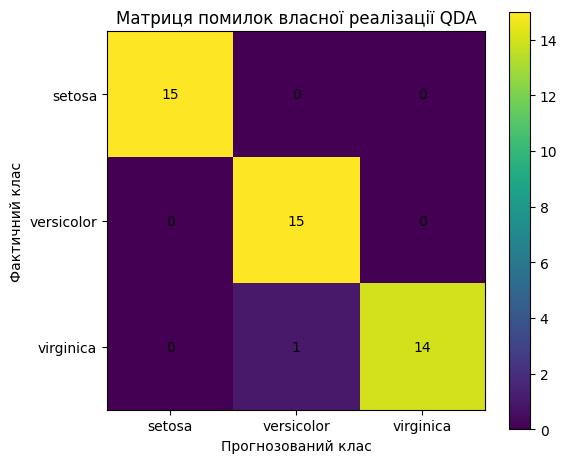

In [11]:
cm = confusion_matrix(y_test, y_pred_custom)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm)
ax.set_xticks(range(len(iris.target_names)))
ax.set_yticks(range(len(iris.target_names)))
ax.set_xticklabels(iris.target_names)
ax.set_yticklabels(iris.target_names)
ax.set_xlabel("Прогнозований клас")
ax.set_ylabel("Фактичний клас")
ax.set_title("Матриця помилок власної реалізації QDA")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


## Висновки

У роботі було реалізовано власний класифікатор QDA. Для кожного класу окремо обчислено середній вектор, коваріаційну матрицю, її обернену матрицю, визначник та апріорну ймовірність.

Власна реалізація використовує квадратичну дискримінантну функцію і вибирає клас із найбільшим її значенням. Для отримання оцінок імовірностей значення дискримінантних функцій нормалізовано за допомогою softmax.

Після порівняння з `QuadraticDiscriminantAnalysis` зі sklearn очікується повний або майже повний збіг прогнозів. Невеликі відмінності у ймовірностях можуть виникати через відмінності у внутрішніх числових обчисленнях, регуляризації та оцінюванні коваріаційних матриць. Якщо прогнози збігаються, а точність однакова або дуже близька, це підтверджує коректність власної реалізації QDA.
